===== HEAD =====
   produto_id  media_score_risco  media_defeitos  percentual_os_altas  \
0      414170           2.674149             1.0                  0.0   
1      621557           2.484907             1.0                  0.0   
2      414824           2.525729             1.0                  0.0   
3      414129           2.140066             1.0                  0.0   
4     1729772           2.525729             1.0                  0.0   

   risco_produto  total_os_log  
0              0      0.693147  
1              0      0.693147  
2              0      0.693147  
3              0      0.693147  
4              0      0.693147  

===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1659 entries, 0 to 1658
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   produto_id           1659 non-null   int64  
 1   media_score_risco    1659 non-null   float64
 2   media_defeitos   

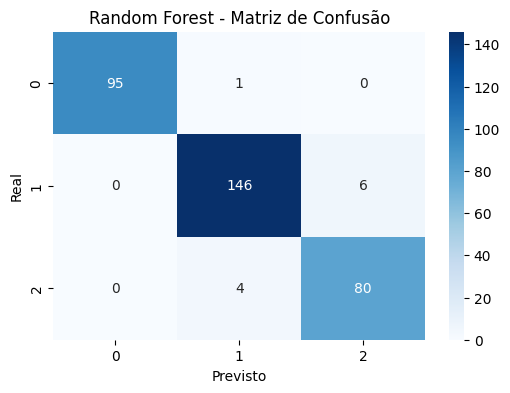


===== FEATURE IMPORTANCE =====
               Feature  Importance
2  percentual_os_altas    0.373367
3         total_os_log    0.314630
0    media_score_risco    0.284340
1       media_defeitos    0.027663


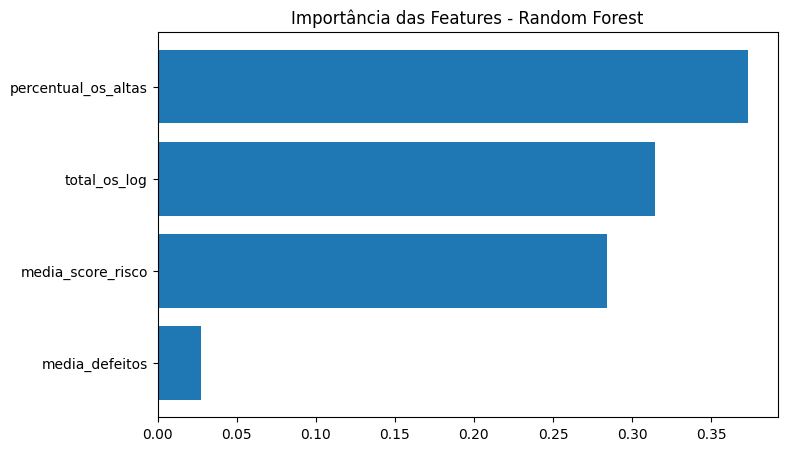


TREINANDO XGBOOST

===== ACURÁCIA XGBOOST =====
0.9728915662650602

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       0.98      0.96      0.97       152
           2       0.93      0.96      0.95        84

    accuracy                           0.97       332
   macro avg       0.97      0.97      0.97       332
weighted avg       0.97      0.97      0.97       332



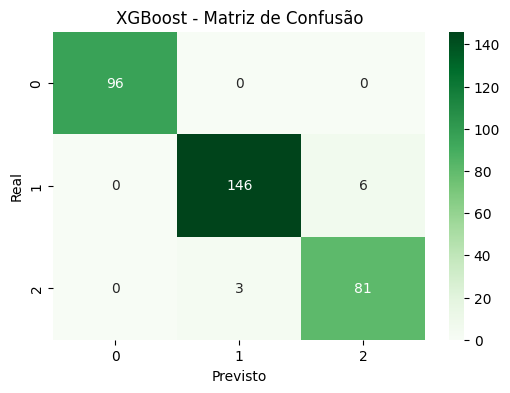


TREINANDO LOGISTIC REGRESSION

===== ACURÁCIA LOGISTIC REGRESSION =====
0.927710843373494

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        96
           1       0.99      0.85      0.91       152
           2       0.83      0.99      0.90        84

    accuracy                           0.93       332
   macro avg       0.92      0.95      0.93       332
weighted avg       0.94      0.93      0.93       332



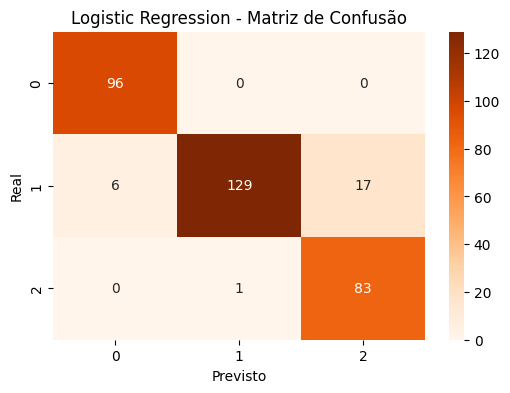


COMPARAÇÃO FINAL
                Modelo  Acurácia
1              XGBoost  0.972892
0        Random Forest  0.966867
2  Logistic Regression  0.927711


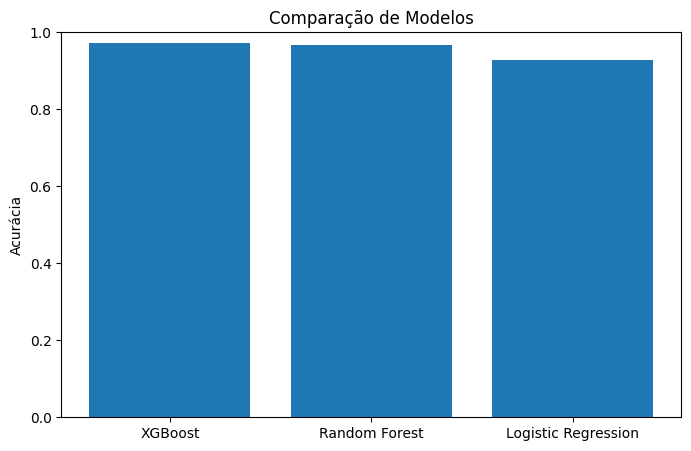


MELHOR MODELO
Modelo: XGBoost
Acurácia: 0.9729


In [ ]:
# DataSentinel - Classificação de Risco de Produtos
# Comparando Random Forest, XGBoost e Logistic Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Carregando o dataset
df = pd.read_csv("dataset_produto_final.csv")

print("===== HEAD =====")
print(df.head())

print("\n===== INFO =====")
print(df.info())

print("\n===== NULOS =====")
print(df.isnull().sum())

print("\n===== DISTRIBUIÇÃO TARGET =====")
print(df["risco_produto"].value_counts())

# Separando features e target
X = df.drop(columns=["produto_id", "risco_produto"])
y = df["risco_produto"]

# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===== TAMANHOS =====")
print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

# ============================================================
# RANDOM FOREST
# ============================================================

print("\n==============================")
print("TREINANDO RANDOM FOREST")
print("==============================")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("\n===== ACURÁCIA RANDOM FOREST =====")
print(rf_acc)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, rf_pred))

# Matriz de confusão
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Random Forest - Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

# Importância das features
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importance", ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(importances)

plt.figure(figsize=(8,5))
plt.barh(importances["Feature"], importances["Importance"])
plt.title("Importância das Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

# ============================================================
# XGBOOST
# ============================================================

print("\n==============================")
print("TREINANDO XGBOOST")
print("==============================")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    objective='multi:softmax',
    num_class=3
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("\n===== ACURÁCIA XGBOOST =====")
print(xgb_acc)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, xgb_pred))

plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, xgb_pred),
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title("XGBoost - Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

# ============================================================
# LOGISTIC REGRESSION
# ============================================================

print("\n==============================")
print("TREINANDO LOGISTIC REGRESSION")
print("==============================")

log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_acc = accuracy_score(y_test, log_pred)

print("\n===== ACURÁCIA LOGISTIC REGRESSION =====")
print(log_acc)

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, log_pred))

plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(y_test, log_pred),
    annot=True,
    fmt='d',
    cmap='Oranges'
)
plt.title("Logistic Regression - Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

# ============================================================
# COMPARAÇÃO FINAL DOS MODELOS
# ============================================================

resultados = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "XGBoost",
        "Logistic Regression"
    ],
    "Acurácia": [
        rf_acc,
        xgb_acc,
        log_acc
    ]
})

resultados = resultados.sort_values(by="Acurácia", ascending=False)

print("\n==============================")
print("COMPARAÇÃO FINAL")
print("==============================")
print(resultados)

plt.figure(figsize=(8,5))
plt.bar(resultados["Modelo"], resultados["Acurácia"])
plt.title("Comparação de Modelos")
plt.ylabel("Acurácia")
plt.ylim(0,1)
plt.show()

# Melhor modelo
melhor_modelo = resultados.iloc[0]

print("\n==============================")
print("MELHOR MODELO")
print("==============================")
print(f"Modelo: {melhor_modelo['Modelo']}")
print(f"Acurácia: {melhor_modelo['Acurácia']:.4f}")



===== NOVOS DADOS =====
   media_score_risco  media_defeitos  percentual_os_altas  total_os_log  \
0           3.609787        1.537740             0.274900      4.368673   
1           1.742176        0.947579             0.098804      1.328223   
2           6.063322        3.720594             0.732063      9.190451   
3           3.732878        4.733062             0.951958      7.268585   
4           1.380391        0.603901             0.144179      2.943552   

   classe_esperada  
0                1  
1                0  
2                2  
3                2  
4                0  

===== TAMANHO =====
(360, 5)

===== DISTRIBUIÇÃO ESPERADA =====
classe_esperada
1    120
0    120
2    120
Name: count, dtype: int64

RESULTADOS NOS NOVOS DADOS
                Modelo  Acurácia_Novos_Dados
2  Logistic Regression              0.708333
0        Random Forest              0.505556
1              XGBoost              0.491667


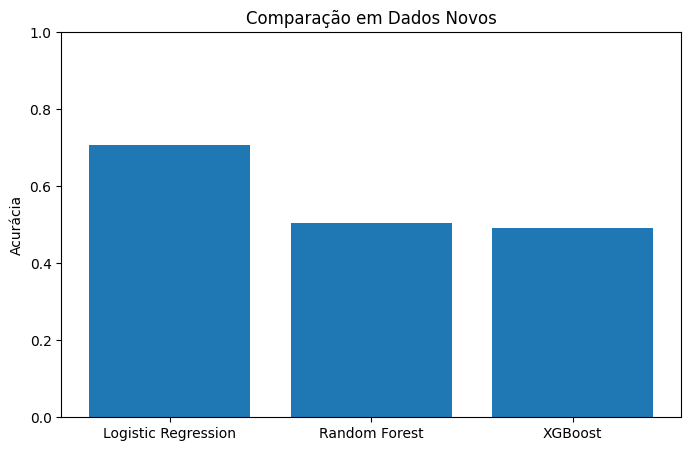

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# CRIANDO UM DATASET MAIOR DE VALIDAÇÃO
# ============================================================

import numpy as np
import pandas as pd

np.random.seed(42)

n_baixo = 120
n_medio = 120
n_alto = 120

# Baixo risco (classe esperada = 0)
baixo = pd.DataFrame({
    "media_score_risco": np.random.normal(loc=1.8, scale=0.5, size=n_baixo),
    "media_defeitos": np.random.normal(loc=0.6, scale=0.3, size=n_baixo),
    "percentual_os_altas": np.random.uniform(0.00, 0.15, n_baixo),
    "total_os_log": np.random.normal(loc=2.0, scale=0.8, size=n_baixo),
    "classe_esperada": 0
})

# Médio risco (classe esperada = 1)
medio = pd.DataFrame({
    "media_score_risco": np.random.normal(loc=3.0, scale=0.7, size=n_medio),
    "media_defeitos": np.random.normal(loc=1.8, scale=0.5, size=n_medio),
    "percentual_os_altas": np.random.uniform(0.20, 0.50, n_medio),
    "total_os_log": np.random.normal(loc=4.0, scale=1.0, size=n_medio),
    "classe_esperada": 1
})

# Alto risco (classe esperada = 2)
alto = pd.DataFrame({
    "media_score_risco": np.random.normal(loc=5.0, scale=0.8, size=n_alto),
    "media_defeitos": np.random.normal(loc=4.0, scale=0.8, size=n_alto),
    "percentual_os_altas": np.random.uniform(0.70, 1.00, n_alto),
    "total_os_log": np.random.normal(loc=8.0, scale=1.2, size=n_alto),
    "classe_esperada": 2
})

# Unindo tudo
novos_dados = pd.concat([baixo, medio, alto], ignore_index=True)

# Removendo valores negativos
colunas_numericas = [
    "media_score_risco",
    "media_defeitos",
    "percentual_os_altas",
    "total_os_log"
]

for col in colunas_numericas:
    novos_dados[col] = novos_dados[col].clip(lower=0)

# Embaralhando
novos_dados = novos_dados.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n===== NOVOS DADOS =====")
print(novos_dados.head())

print("\n===== TAMANHO =====")
print(novos_dados.shape)

print("\n===== DISTRIBUIÇÃO ESPERADA =====")
print(novos_dados["classe_esperada"].value_counts())

# Separando features
X_novos = novos_dados.drop(columns=["classe_esperada"])

# Previsões dos três modelos
rf_pred_novos = rf_model.predict(X_novos)
xgb_pred_novos = xgb_model.predict(X_novos)
log_pred_novos = log_model.predict(X_novos)

novos_dados["RF_Pred"] = rf_pred_novos
novos_dados["XGB_Pred"] = xgb_pred_novos
novos_dados["LOG_Pred"] = log_pred_novos

# Acurácia dos modelos nos novos dados
from sklearn.metrics import accuracy_score

rf_acc_novos = accuracy_score(novos_dados["classe_esperada"], rf_pred_novos)
xgb_acc_novos = accuracy_score(novos_dados["classe_esperada"], xgb_pred_novos)
log_acc_novos = accuracy_score(novos_dados["classe_esperada"], log_pred_novos)

resultados_novos = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "XGBoost",
        "Logistic Regression"
    ],
    "Acurácia_Novos_Dados": [
        rf_acc_novos,
        xgb_acc_novos,
        log_acc_novos
    ]
})

resultados_novos = resultados_novos.sort_values(by="Acurácia_Novos_Dados", ascending=False)

print("\n==============================")
print("RESULTADOS NOS NOVOS DADOS")
print("==============================")
print(resultados_novos)

plt.figure(figsize=(8,5))
plt.bar(resultados_novos["Modelo"], resultados_novos["Acurácia_Novos_Dados"])
plt.title("Comparação em Dados Novos")
plt.ylabel("Acurácia")
plt.ylim(0,1)
plt.show()

# Exportando resultados
novos_dados.to_excel("validacao_novos_dados.xlsx", index=False)
resultados_novos.to_excel("comparacao_modelos_novos_dados.xlsx", index=False)

from google.colab import files

files.download("validacao_novos_dados.xlsx")
files.download("comparacao_modelos_novos_dados.xlsx")



===== NOVOS DADOS =====
   media_score_risco  media_defeitos  percentual_os_altas  total_os_log  \
0             2.6911          0.3565               0.0535        5.7367   
1             2.1704          1.2324               0.0159        1.2069   
2             3.3192          0.4367               0.0138        3.9396   
3             3.1162          0.8811               0.5109        9.8612   
4             1.8223          0.7455               0.0090        2.0556   

   classe_esperada  
0                1  
1                0  
2                2  
3                2  
4                0  

===== TAMANHO =====
(360, 5)

===== DISTRIBUIÇÃO ESPERADA =====
classe_esperada
1    120
0    120
2    120
Name: count, dtype: int64

RESULTADOS NOS NOVOS DADOS
                Modelo  Acurácia_Novos_Dados
2  Logistic Regression              0.850000
1              XGBoost              0.805556
0        Random Forest              0.738889


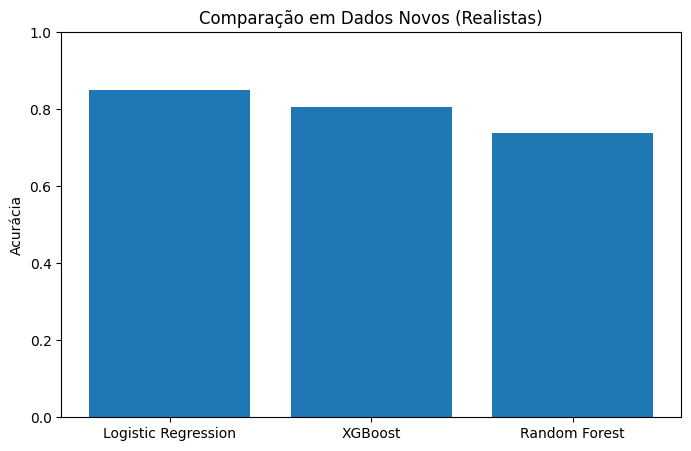

In [8]:
# Criando um dataset de validação com a mesma distribuição do dataset original

import numpy as np
import pandas as pd

np.random.seed(42)

n_baixo = 120
n_medio = 120
n_alto = 120

# Baixo risco (classe esperada = 0)
baixo = pd.DataFrame({
    "media_score_risco": np.random.normal(loc=2.226, scale=0.481, size=n_baixo),
    "media_defeitos": np.random.normal(loc=0.740, scale=0.425, size=n_baixo),
    "percentual_os_altas": np.random.normal(loc=0.0, scale=0.01, size=n_baixo),
    "total_os_log": np.random.normal(loc=1.204, scale=0.549, size=n_baixo),
    "classe_esperada": 0
})

# Médio risco (classe esperada = 1)
medio = pd.DataFrame({
    "media_score_risco": np.random.normal(loc=2.648, scale=0.237, size=n_medio),
    "media_defeitos": np.random.normal(loc=0.878, scale=0.335, size=n_medio),
    "percentual_os_altas": np.random.normal(loc=0.090, scale=0.082, size=n_medio),
    "total_os_log": np.random.normal(loc=3.349, scale=1.293, size=n_medio),
    "classe_esperada": 1
})

# Alto risco (classe esperada = 2)
alto = pd.DataFrame({
    "media_score_risco": np.random.normal(loc=3.128, scale=0.486, size=n_alto),
    "media_defeitos": np.random.normal(loc=0.948, scale=0.446, size=n_alto),
    "percentual_os_altas": np.random.normal(loc=0.359, scale=0.282, size=n_alto),
    "total_os_log": np.random.normal(loc=4.345, scale=2.557, size=n_alto),
    "classe_esperada": 2
})

# Unindo tudo
novos_dados = pd.concat([baixo, medio, alto], ignore_index=True)

# Removendo valores negativos e limitando percentual entre 0 e 1
colunas_numericas = [
    "media_score_risco",
    "media_defeitos",
    "percentual_os_altas",
    "total_os_log"
]

for col in colunas_numericas:
    novos_dados[col] = novos_dados[col].clip(lower=0)

novos_dados["percentual_os_altas"] = novos_dados["percentual_os_altas"].clip(upper=1)

# Embaralhando
novos_dados = novos_dados.sample(frac=1, random_state=42).reset_index(drop=True)
novos_dados = novos_dados.round(4)

print("\n===== NOVOS DADOS =====")
print(novos_dados.head())

print("\n===== TAMANHO =====")
print(novos_dados.shape)

print("\n===== DISTRIBUIÇÃO ESPERADA =====")
print(novos_dados["classe_esperada"].value_counts())

# Separando features
X_novos = novos_dados.drop(columns=["classe_esperada"])

# Previsões dos três modelos
rf_pred_novos = rf_model.predict(X_novos)
xgb_pred_novos = xgb_model.predict(X_novos)
log_pred_novos = log_model.predict(X_novos)

novos_dados["RF_Pred"] = rf_pred_novos
novos_dados["XGB_Pred"] = xgb_pred_novos
novos_dados["LOG_Pred"] = log_pred_novos

# Acurácia dos modelos nos novos dados
rf_acc_novos = accuracy_score(novos_dados["classe_esperada"], rf_pred_novos)
xgb_acc_novos = accuracy_score(novos_dados["classe_esperada"], xgb_pred_novos)
log_acc_novos = accuracy_score(novos_dados["classe_esperada"], log_pred_novos)

resultados_novos = pd.DataFrame({
    "Modelo": [
        "Random Forest",
        "XGBoost",
        "Logistic Regression"
    ],
    "Acurácia_Novos_Dados": [
        rf_acc_novos,
        xgb_acc_novos,
        log_acc_novos
    ]
})

resultados_novos = resultados_novos.sort_values(by="Acurácia_Novos_Dados", ascending=False)

print("\n==============================")
print("RESULTADOS NOS NOVOS DADOS")
print("==============================")
print(resultados_novos)

plt.figure(figsize=(8,5))
plt.bar(resultados_novos["Modelo"], resultados_novos["Acurácia_Novos_Dados"])
plt.title("Comparação em Dados Novos (Realistas)")
plt.ylabel("Acurácia")
plt.ylim(0,1)
plt.show()